# Investigate Hotel Business Using Data Visualization

## Understanding Hotel Booking and Cancellation Behaviour

### Project Overview

Hotels receive a large number of bookings from different types of customers. However, not every booking is completed because some customers cancel their reservations before arrival. These cancellations can affect room availability, revenue, staff planning, and overall hotel performance.

In this project, I am using hotel booking data to understand how customers make their bookings and what factors are related to cancellations. Instead of looking at the data only as numbers, I will use **data analysis and visualization** to find useful patterns and present them in an easy-to-understand way.

The analysis mainly focuses on three important areas:

* **Hotel type:** Understanding whether customers book City Hotel or Resort Hotel more often.
* **Stay duration:** Checking whether the number of nights a customer plans to stay is related to the chance of cancellation.
* **Lead time:** Understanding whether the number of days between making a booking and the arrival date affects cancellation behaviour.

Before performing these analyses, I will first clean and understand the dataset. This includes checking the data structure, missing values, duplicate records, incorrect or unusual values, and other data-quality issues. After cleaning the data, I will perform **Exploratory Data Analysis (EDA)** to understand the main patterns in the dataset.

I will then create different charts to visualize the results. These visualizations will help me compare hotel types, understand monthly booking patterns, and identify factors that may be connected with higher cancellation rates.

Finally, I will use the findings from the analysis to give **business recommendations**. The purpose is not only to find percentages or create charts, but to understand what these results could mean for hotel management and how the information can be used for better booking, demand, and cancellation management.

### Business Problem

From a hotel's point of view, a booking is important because it represents expected occupancy and revenue. When customers cancel, rooms that were expected to be occupied may become available again, sometimes at short notice. This can make it difficult for the hotel to plan rooms, staff, pricing, and marketing activities.

Therefore, by studying past booking data, we can identify customer booking patterns and find situations where cancellations are more common. This can help hotel management make better decisions based on actual data.

### Business Questions

To understand the booking and cancellation behaviour, this project will answer the following questions:

1. **Which hotel type receives more bookings?**
   I will compare City Hotel and Resort Hotel to understand where most of the bookings are coming from.

2. **How does booking demand change over different months?**
   I will analyze the number of bookings by month to identify busy and less busy periods and understand seasonal booking patterns.

3. **Does the length of stay affect cancellation behaviour?**
   I will compare the planned stay duration with cancellation rates to see whether longer or shorter stays have different cancellation patterns.

4. **Does lead time affect the cancellation rate?**
   I will study how cancellation behaviour changes depending on how many days before arrival the customer makes the booking.

5. **Which booking patterns indicate a higher cancellation risk?**
   By combining the findings from stay duration and lead time analysis, I will identify the booking situations that may need more attention from hotel management.

### Project Objective

The main objective of this project is to use hotel booking data to understand **booking demand and cancellation behaviour** through data analysis and visualization.

The project aims to:

* Clean and prepare the hotel booking dataset for analysis.
* Understand the important variables and their meaning.
* Perform Exploratory Data Analysis (EDA) to identify useful patterns.
* Compare booking behaviour between City Hotel and Resort Hotel.
* Identify monthly booking trends and seasonal demand.
* Analyze the relationship between stay duration and cancellation rate.
* Analyze the relationship between lead time and cancellation rate.
* Convert the analysis results into simple and useful business insights.
* Provide recommendations that can help hotel management improve demand planning and reduce the impact of cancellations.

### Project Approach

The project will be completed in the following order:

**Understand the Data → Clean the Data → Explore the Data → Create Visualizations → Interpret the Results → Give Business Recommendations**

This approach helps ensure that the final recommendations are based on the actual information present in the dataset rather than assumptions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Set chart style
sns.set_theme(style="whitegrid")

# Data Preprocessing

Before starting the actual analysis, we first need to make sure that the hotel booking data is ready to use. The data collected from real bookings may contain missing information, duplicate records, unclear values, or unusual records. If we use such data directly, it can affect our calculations and charts and may lead to incorrect conclusions.

**Data preprocessing** means checking and preparing the raw dataset before using it for analysis. In this project, I will examine the hotel booking data and identify problems that may affect the results.

The main purpose of this step is to make the dataset more **clean, consistent, and reliable** so that the analysis performed later is based on good-quality data.

### What We Will Check

The preprocessing stage includes the following steps:

1. **Understand the dataset**
   First, I will check the number of rows and columns, column names, data types, and the type of information available in the dataset. This helps me understand what kind of data I am working with before starting the analysis.

2. **Check missing values**
   Missing values mean that some information is not available for certain bookings. I will identify which columns contain missing values and decide how they should be handled. This is important because missing data can affect calculations and visualizations.

3. **Check duplicate records**
   A duplicate record means that the same booking information appears more than once. If duplicates are not handled, the same booking could be counted multiple times and give an incorrect picture of booking demand.

4. **Check inconsistent or unclear values**
   Some columns may contain values that are unclear, inconsistent, or not useful for analysis. For example, a category may contain an `Undefined` value instead of a meaningful category. Such values need to be checked before continuing.

5. **Check unusual or invalid records**
   Some records may contain values that do not make business sense or are very different from normal observations. Examples include bookings with zero guests, negative values, or unusual **ADR (Average Daily Rate)** values. These records need to be investigated and handled appropriately.

### Why Is Data Preprocessing Important?

Data preprocessing is important because the quality of our analysis depends on the quality of the data we use.

For example, if duplicate bookings are counted twice, the total number of bookings will be higher than the actual number. Similarly, if an invalid ADR value is included, it can affect the average room price.

Therefore, before creating charts or calculating cancellation rates, I will first check and prepare the dataset. Once the data is cleaned, it can be used for **Exploratory Data Analysis (EDA), visualization, and further business analysis**.

## Data Overview

After introducing the project, the next step is to understand the dataset we are going to work with. Before creating any charts or calculating results, it is important to know **what information each column contains and how that information can be used in our analysis**.

The dataset contains hotel booking information from **2017 to 2019**. Each row represents a hotel booking, and the columns contain different details about that booking, such as the type of hotel, arrival date, length of stay, number of guests, room price, and cancellation status.

For this project, I will mainly use the following columns:

* **`hotel`** – Tells us whether the booking was made for a **City Hotel** or a **Resort Hotel**. This helps us compare the booking and cancellation behaviour of the two hotel types.

* **`is_canceled`** – Tells us whether the booking was canceled or completed. A value of `1` represents a canceled booking, while `0` represents a booking that was not canceled. This column is important for calculating the cancellation rate.

* **`lead_time`** – Shows the number of days between the date when the customer made the booking and the planned arrival date. This helps us understand whether booking earlier or closer to the arrival date is related to cancellation behaviour.

* **`arrival_date_year` and `arrival_date_month`** – Provide the year and month of the customer's planned arrival. These columns are used to study how booking demand changes over time and to identify busy or less busy months.

* **`stays_in_weekend_nights` and `stays_in_weekdays_nights`** – Show the number of weekend and weekday nights included in the booking. These columns are combined to calculate the customer's **total stay duration**.

* **`adults`, `children`, and `babies`** – Show the number of guests included in the booking. These columns can be used to understand the size of the group and also help us identify unusual bookings, such as a booking with no guests.

* **`adr`** – Stands for **Average Daily Rate**. It represents the average amount charged per room per day for a booking. This helps us understand the pricing information in the dataset and identify unusual or invalid price values.

Understanding these columns is important because they provide the information needed to answer the business questions defined at the beginning of the project.


In [2]:
df = pd.read_csv("hotel_bookings_data.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,meal,city,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Direct,Direct,0,0,0,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Corporate,Corporate,0,0,0,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,0.0,0,Breakfast,Kabupaten Bangka,Online TA,TA/TO,0,0,0,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 119390
Number of Columns: 29


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Missing Values

The dataset was checked for missing values to identify columns with incomplete information. Four columns contain missing values: `company`, `agent`, `city`, and `children`.

Each missing value was handled based on the meaning of the respective column. Rather than removing a large number of rows, missing values were replaced with meaningful values where appropriate to preserve the size of the dataset for further analysis.


In [5]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

company     112593
agent        16340
city           488
children         4
dtype: int64

In [6]:
# Create a copy of the original dataset before cleaning
df_clean = df.copy()

# Replace missing company values with 0
df_clean['company'] = df_clean['company'].fillna(0)

# Replace missing agent values with 0
df_clean['agent'] = df_clean['agent'].fillna(0)

# Replace missing city values with 'Unknown'
df_clean['city'] = df_clean['city'].fillna('Unknown')

# Replace missing children values with 0
df_clean['children'] = df_clean['children'].fillna(0)

### Handling Missing Values

**Company:** The `company` column contains 112,593 missing values. Since most bookings do not appear to be associated with a company, the missing values were replaced with `0`, representing no company information available.

**Agent:** The `agent` column contains 16,340 missing values. Missing values were replaced with `0`, indicating that no travel agent information was recorded for those bookings.

**City:** The `city` column contains 488 missing values. These missing values were replaced with `"Unknown"` because the customer's city information was not available.

**Children:** The `children` column contains only 4 missing values. These were replaced with `0`, assuming that no children information was recorded for those bookings.

This approach preserves all booking records and avoids removing a large number of observations from the dataset.

### Duplicate Rows

A duplicate row is a record that appears more than once in the dataset with the same or repeated information. In simple words, the same booking information may be recorded multiple times.

Duplicate records can create a problem during analysis because they can make the number of bookings appear higher than it actually is. They can also affect calculations such as booking percentages, cancellation rates, averages, and other results.

In [7]:
missing_after_cleaning = df_clean.isnull().sum()

print(missing_after_cleaning[missing_after_cleaning > 0])

Series([], dtype: int64)


In [8]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 33261


In [9]:
df_clean[df_clean.duplicated()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,meal,city,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
5,Resort Hotel,0,14,2017,September,27,1,0,2,2,0.0,0,Breakfast,Kabupaten Bangka,Online TA,TA/TO,0,0,0,0,No Deposit,240.0,0.0,0,Personal,98.00,0,1,Check-Out
22,Resort Hotel,0,72,2017,September,27,1,2,4,2,0.0,0,Breakfast,Kota Denpasar,Direct,Direct,0,0,0,1,No Deposit,250.0,0.0,0,Personal,84.67,0,1,Check-Out
43,Resort Hotel,0,70,2017,September,27,2,2,3,2,0.0,0,Dinner,Kabupaten Tangerang,Direct,Direct,0,0,0,0,No Deposit,250.0,0.0,0,Personal,137.00,0,1,Check-Out
138,Resort Hotel,1,5,2017,September,28,5,1,0,2,0.0,0,Breakfast,Kota Denpasar,Online TA,TA/TO,0,0,0,0,No Deposit,240.0,0.0,0,Personal,97.00,0,0,Canceled
200,Resort Hotel,0,0,2017,September,28,7,0,1,1,0.0,0,Breakfast,Kabupaten Bangka,Online TA,TA/TO,0,0,0,0,No Deposit,240.0,0.0,0,Personal,109.80,0,3,Check-Out


In [10]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (86129, 29)


In [11]:
# Verify that duplicates have been removed
print("Duplicate rows remaining:", df_clean.duplicated().sum())

Duplicate rows remaining: 0


#### Therefore, after checking the dataset, I found 33,261 duplicate rows.

After removing duplicate records, the dataset was checked again to confirm that no duplicate rows remained. Removing duplicates helps prevent repeated records from influencing booking counts, cancellation rates, and other analysis results.

### Inconsistent and Unclear Values

The `meal` column was examined to identify inconsistent or unclear categories. The dataset contained 454 records with the value `"Undefined"`.

Since `"Undefined"` does not represent a clear meal category, these records were recategorized as `"No Meal"`. This approach preserves the booking records while making the meal categories easier to interpret during analysis.

The final meal categories were:
Breakfast
No Meal
Dinner
Full Board


In [12]:
df_clean['meal'].value_counts(dropna=False)

meal
Breakfast     67088
No Meal        9442
Dinner         8798
Undefined       454
Full Board      347
Name: count, dtype: int64

In [13]:
# Replace Undefined meal category with No Meal
df_clean['meal'] = df_clean['meal'].replace('Undefined', 'No Meal')

# Check the updated categories
df_clean['meal'].value_counts()

meal
Breakfast     67088
No Meal        9896
Dinner         8798
Full Board      347
Name: count, dtype: int64

### ADR Anomalies

Before using the adr column in our analysis, we need to check whether its values are reasonable.

ADR stands for Average Daily Rate. It represents the average amount charged for a hotel room for one day. Since a hotel normally charges a positive amount for a room, a negative ADR does not make business sense.

We also need to look for unusually high ADR values. An unusually high value is called an outlier. An outlier is a value that is very different from most of the other values in the dataset.

Outliers are important because they can affect calculations such as the average and can also make charts difficult to understand. For example, if most ADR values are around ₹100 but one record has an ADR of 5400, that one value is much larger than the normal range and can make the overall distribution look misleading.

To understand the ADR distribution, I checked its minimum, maximum, median, and other statistical values.


In [14]:
# Check summary statistics for Average Daily Rate
df_clean['adr'].describe()

count    86129.000000
mean       106.634109
std         55.175319
min         -6.380000
25%         72.250000
50%         98.750000
75%        134.510000
max       5400.000000
Name: adr, dtype: float64

In [15]:
# Check negative ADR values
negative_adr = df_clean[df_clean['adr'] < 0]

print("Number of negative ADR values:", len(negative_adr))

negative_adr[[
    'hotel',
    'is_canceled',
    'lead_time',
    'adults',
    'children',
    'babies',
    'adr'
]]

Number of negative ADR values: 1


,hotel,is_canceled,lead_time,adults,children,babies,adr
14969,Resort Hotel,0,195,2,0.0,0,-6.38


In [16]:
# View the highest ADR values
df_clean[[
    'hotel',
    'adr',
    'lead_time',
    'adults',
    'children',
    'babies'
]].sort_values(
    by='adr',
    ascending=False
).head(10)

,hotel,adr,lead_time,adults,children,babies
48515,City Hotel,5400.00,35,2,0.0,0
111403,City Hotel,510.00,0,1,0.0,0
15083,Resort Hotel,508.00,1,2,0.0,0
103912,City Hotel,451.50,81,2,2.0,0
13142,Resort Hotel,450.00,378,2,0.0,0
13391,Resort Hotel,437.00,59,2,2.0,0
39155,Resort Hotel,426.25,31,2,2.0,0
39568,Resort Hotel,402.00,104,3,1.0,0
39118,Resort Hotel,397.38,26,3,2.0,0
13323,Resort Hotel,392.00,116,2,1.0,0


In [17]:
# Count unusually high ADR values
print("ADR values above 500:", (df_clean['adr'] > 500).sum())
print("ADR values above 1000:", (df_clean['adr'] > 1000).sum())

ADR values above 500: 3
ADR values above 1000: 1


In [18]:
# Display all bookings with ADR above 500
df_clean[df_clean['adr'] > 500][[
    'hotel',
    'is_canceled',
    'lead_time',
    'adults',
    'children',
    'babies',
    'adr'
]].sort_values(by='adr', ascending=False)

,hotel,is_canceled,lead_time,adults,children,babies,adr
48515,City Hotel,1,35,2,0.0,0,5400.0
111403,City Hotel,0,0,1,0.0,0,510.0
15083,Resort Hotel,0,1,2,0.0,0,508.0


In [19]:
# Remove the identified extreme ADR outlier
df_clean = df_clean[df_clean['adr'] != 5400]

print("Dataset shape after removing extreme ADR outlier:", df_clean.shape)

# Check maximum ADR after cleaning
print("Maximum ADR after cleaning:", df_clean['adr'].max())

Dataset shape after removing extreme ADR outlier: (86128, 29)
Maximum ADR after cleaning: 510.0


In [20]:
# Remove records with negative ADR values
df_clean = df_clean[df_clean['adr'] >= 0]

print("Number of negative ADR values remaining:", (df_clean['adr'] < 0).sum())
print("Dataset shape after ADR cleaning:", df_clean.shape)

Number of negative ADR values remaining: 0
Dataset shape after ADR cleaning: (86127, 29)


### ADR Cleaning Decision

After identifying the unusual ADR values, the next step is to decide which records should actually be removed.

First, one booking had an ADR of **-6.38**. Since ADR represents the average daily room rate, a negative value is not meaningful for this analysis. Therefore, this record was removed.

There were also three bookings with an ADR above **500**. However, a high ADR does not automatically mean that the booking is incorrect. Hotels can charge higher prices for premium rooms, special bookings, or other situations.

After checking these records, the ADR value of **5400** was considered an extreme outlier because it was far outside the normal range of the dataset. It was removed so that it would not have an unnecessary effect on our analysis and visualizations.

The other high ADR values were kept because they could still represent genuine hotel bookings.

Therefore, the cleaning decision was:

* Remove the **negative ADR value (-6.38)** because it is not meaningful.
* Remove the **extreme ADR value (5400)** because it is unusually far from the normal values.
* Keep the other high ADR values because they may represent valid bookings.

After this step, the dataset no longer contains the identified negative ADR value or the extreme ADR outlier.



### Bookings with No Guests

The total number of guests was calculated by combining the number of adults, children, and babies recorded for each booking.

A total of **165 bookings** were found where the number of adults, children, and babies was zero. These records do not represent meaningful hotel stays because no guests were recorded for the booking.

Therefore, these records were removed from the dataset to ensure that the analysis is based on valid guest bookings.


In [21]:
# Calculate the total number of guests
df_clean['total_guests'] = (
    df_clean['adults'] +
    df_clean['children'] +
    df_clean['babies']
)

# Count bookings with zero guests
zero_guest_bookings = df_clean[df_clean['total_guests'] == 0]

print("Number of bookings with zero guests:", len(zero_guest_bookings))

Number of bookings with zero guests: 165


In [22]:
# Display a sample of bookings with zero guests
zero_guest_bookings[[
    'hotel',
    'is_canceled',
    'lead_time',
    'adults',
    'children',
    'babies',
    'adr'
]].head(10)

,hotel,is_canceled,lead_time,adults,children,babies,adr
2224,Resort Hotel,0,1,0,0.0,0,0.0
2409,Resort Hotel,0,0,0,0.0,0,0.0
3181,Resort Hotel,0,36,0,0.0,0,0.0
3684,Resort Hotel,0,165,0,0.0,0,0.0
3708,Resort Hotel,0,165,0,0.0,0,0.0
4127,Resort Hotel,1,0,0,0.0,0,0.0
9376,Resort Hotel,1,0,0,0.0,0,0.0
31765,Resort Hotel,0,31,0,0.0,0,28.0
32029,Resort Hotel,0,4,0,0.0,0,0.0
32827,Resort Hotel,0,46,0,0.0,0,0.0


In [23]:
# Remove bookings with no guests
df_clean = df_clean[df_clean['total_guests'] > 0]

print("Dataset shape after removing zero-guest bookings:", df_clean.shape)
print("Zero-guest bookings remaining:", (df_clean['total_guests'] == 0).sum())

Dataset shape after removing zero-guest bookings: (85962, 30)
Zero-guest bookings remaining: 0


### Zero-Guest Cleaning Decision

A total of **165 bookings** were found where the number of adults, children, and babies was zero. These records do not represent meaningful hotel stays because no guests were recorded for the booking.

Therefore, these records were removed from the dataset to ensure that the analysis is based on valid guest bookings.


In [24]:
print("Final dataset shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nDuplicate rows:", df_clean.duplicated().sum())

print("\nNegative ADR values:", (df_clean['adr'] < 0).sum())

print("\nZero-guest bookings:", (df_clean['total_guests'] == 0).sum())

Final dataset shape: (85962, 30)

Missing values:
Series([], dtype: int64)

Duplicate rows: 0

Negative ADR values: 0

Zero-guest bookings: 0


### Conclusion

After completing the data preprocessing steps, the hotel booking dataset is now cleaned and ready for further analysis.

During preprocessing, I checked the dataset for different data-quality problems. This included handling missing values, identifying and removing duplicate records, correcting unclear meal categories, checking unusual ADR values, removing invalid and extreme ADR records, and identifying bookings where no guests were recorded.

The original dataset contained **119,391 records**. After removing the records that were identified as duplicates, invalid ADR values, and bookings with zero recorded guests, the final cleaned dataset contains **85,962 records**.

These preprocessing steps are important because using unclean data could affect the calculations, charts, and conclusions of the project. By preparing the dataset first, I can now continue with the analysis using more reliable and meaningful booking data.

The cleaned dataset is now ready for the next stage: **Exploratory Data Analysis (EDA) and Data Visualization**, where I will explore the booking patterns, cancellation behaviour, stay duration, lead time, and other important factors in the dataset.


# Exploratory Data Analysis

After completing the data preprocessing, the dataset is cleaned and ready to be explored. In the preprocessing stage, I focused on improving the quality of the data by checking and handling issues such as missing values, duplicate records, unclear categories, unusual ADR values, and bookings with no recorded guests.

Now, the next step is to understand **what the cleaned data is telling us**.

### What is Exploratory Data Analysis?

**Exploratory Data Analysis (EDA)** is the process of examining a dataset to understand its main characteristics, find patterns, compare different groups, and identify relationships between variables.

In simple words, EDA helps us answer questions such as:

* What does the booking data look like?
* Which hotel type receives more bookings?
* How does booking demand change over time?
* What patterns can we see in customer bookings?
* How common are cancellations?
* Which booking characteristics may be related to cancellations?

EDA is important because looking at raw data alone can make it difficult to understand these patterns. By using calculations, comparisons, and visualizations, we can convert the raw booking records into information that is easier to understand.

### What Will We Analyze?

In this project, the EDA will focus mainly on **hotel booking patterns and cancellation behaviour**.

First, I will compare **City Hotel and Resort Hotel** to understand the distribution of bookings between the two hotel types.

Next, I will study **monthly booking trends** to understand how booking demand changes during different months and identify periods with higher or lower demand.

After understanding booking demand, I will focus on **cancellation behaviour**. I will examine the overall cancellation pattern and compare cancellation rates between the two hotel types.

I will then investigate two important booking characteristics that may be related to cancellations:

* **Stay Duration:** The total number of nights included in a booking. This will help us understand whether shorter or longer stays show different cancellation patterns.
* **Lead Time:** The number of days between the booking date and the planned arrival date. This will help us understand whether customers who book further in advance behave differently from customers who book closer to their arrival date.

Throughout this stage, I will use **charts and visualizations** to make the patterns easier to identify. Each analysis will be followed by an interpretation explaining what the result means and how it may be useful from a hotel business perspective.

The main purpose of this EDA stage is therefore to move from **cleaned data to meaningful insights** about hotel demand and cancellation behaviour.



## Booking Analysis by Hotel Type

The first step is to understand how bookings are distributed between the two hotel types in the dataset: **City Hotel** and **Resort Hotel**.

This chart compares the number of bookings received by each hotel type. By looking at this comparison, we can get a basic idea of **which type of hotel has greater customer demand** in the dataset.

This is a useful starting point because the booking volume may be different for the two hotel types. Understanding this difference will help us later when we compare their booking trends and cancellation behaviour.


In [25]:
# Count bookings by hotel type
hotel_booking_counts = df_clean['hotel'].value_counts()

print(hotel_booking_counts)

hotel
City Hotel      52421
Resort Hotel    33541
Name: count, dtype: int64


In [26]:
print("Current df_clean shape:", df_clean.shape)

print("\nBookings by hotel type:")
print(df_clean['hotel'].value_counts())

print("\nTotal hotel bookings counted:", df_clean['hotel'].value_counts().sum())

Current df_clean shape: (85962, 30)

Bookings by hotel type:
hotel
City Hotel      52421
Resort Hotel    33541
Name: count, dtype: int64

Total hotel bookings counted: 85962


In [28]:
# Calculate booking percentage by hotel type
hotel_booking_percentage = (
    df_clean['hotel']
    .value_counts(normalize=True)
    * 100
).round(2)

print(hotel_booking_percentage)

hotel
City Hotel      60.98
Resort Hotel    39.02
Name: proportion, dtype: float64


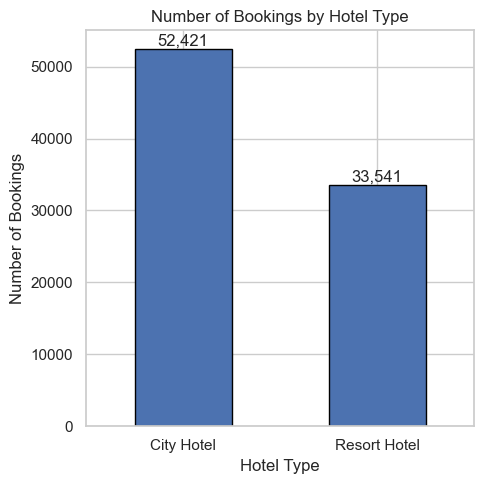

In [29]:
# Create a bar chart for bookings by hotel type
plt.figure(figsize=(5, 5))

hotel_booking_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Number of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=0)

# Add value labels on bars
for i, value in enumerate(hotel_booking_counts.values):
    plt.text(
        i,
        value + 500,
        f'{value:,}',
        ha='center'
    )

plt.tight_layout()
plt.show()

**Chart Caption:** This chart compares the share of total bookings received by City Hotel and Resort Hotel.


### Interpretation

The analysis shows that **City Hotels received more bookings than Resort Hotels**.

City Hotels accounted for **60.98% of all bookings**, with **52,421 bookings**, while Resort Hotels accounted for **39.02%**, with **33,541 bookings**.

This means that, in the cleaned dataset, **City Hotels had higher overall booking demand than Resort Hotels**. This difference gives us a useful starting point for comparing the booking patterns and cancellation behaviour of the two hotel types in the next analyses.


### Monthly Booking Trends

After comparing the overall bookings of City Hotels and Resort Hotels, the next step is to understand **how booking demand changes from month to month**.

This chart compares the **number of bookings for each month** for City Hotels and Resort Hotels. By looking at the monthly pattern, we can identify which months have relatively higher or lower booking demand and see whether the two hotel types follow a similar or different pattern.

Understanding these monthly trends is useful for identifying **seasonal demand**, which can help hotels plan room availability, staff, pricing, and marketing activities more effectively.


In [30]:
# Count bookings by arrival month and hotel type
monthly_bookings = (
    df_clean
    .groupby(['arrival_date_month', 'hotel'])
    .size()
    .reset_index(name='booking_count')
)

monthly_bookings.head()

,arrival_date_month,hotel,booking_count
0,April,City Hotel,3546
1,April,Resort Hotel,2474
2,August,City Hotel,4919
3,August,Resort Hotel,2729
4,December,City Hotel,4048


In [31]:
# Define the correct chronological order of months
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Convert month column to an ordered categorical variable
monthly_bookings['arrival_date_month'] = pd.Categorical(
    monthly_bookings['arrival_date_month'],
    categories=month_order,
    ordered=True
)

# Sort the data by month
monthly_bookings = monthly_bookings.sort_values('arrival_date_month')

monthly_bookings.head()

,arrival_date_month,hotel,booking_count
8,January,City Hotel,2875
9,January,Resort Hotel,2026
6,February,City Hotel,2967
7,February,Resort Hotel,2096
15,March,Resort Hotel,1932


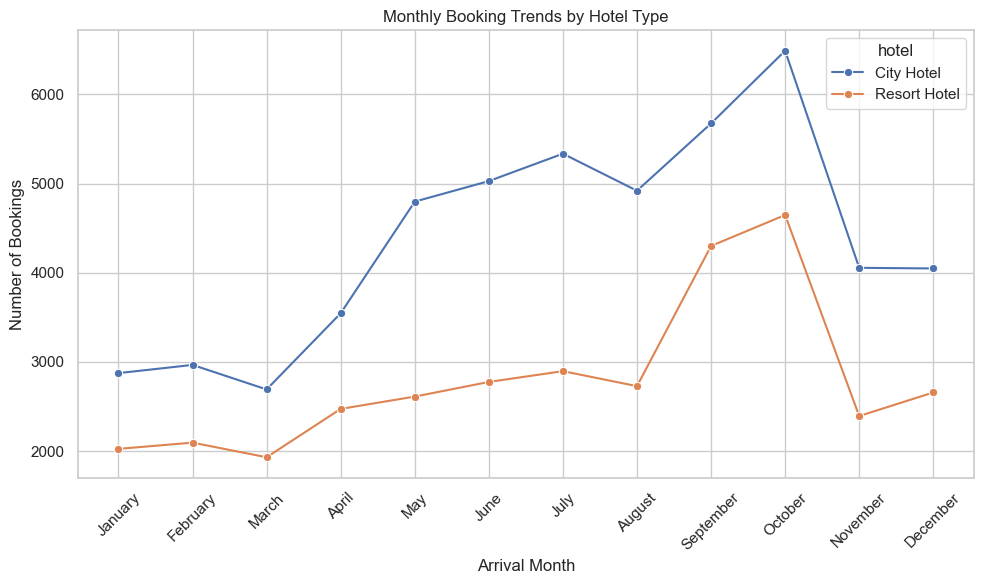

In [32]:
# Create a line chart showing monthly bookings by hotel type
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_bookings,
    x='arrival_date_month',
    y='booking_count',
    hue='hotel',
    marker='o'
)

plt.title('Monthly Booking Trends by Hotel Type')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Chart Caption:** This chart shows how the number of bookings changes across different months for City Hotel and Resort Hotel.


### Interpretation

The monthly booking analysis shows that both City Hotels and Resort Hotels experienced changes in booking demand throughout the year.

For City Hotels, bookings were lowest in **March (2,692 bookings)** and increased substantially during the middle and later months of the year. The highest number of City Hotel bookings was recorded in **October (6,488 bookings)**, followed by **September (5,673)** and **July (5,334)**.

Resort Hotels also experienced their lowest booking level in **March (1,932 bookings)**. Booking demand increased towards the later months of the year, with the highest number of Resort Hotel bookings recorded in **October (4,647 bookings)**, followed by **September (4,300 bookings)**.

Overall, City Hotels received more bookings than Resort Hotels in every month. Both hotel types show a similar pattern of increasing bookings from the earlier months towards September and October, followed by a decline in November and December.

### Note

The monthly booking analysis combines bookings from all available years in the dataset. Therefore, the chart represents general seasonal booking patterns rather than a year-by-year booking trend.


## Cancellation Analysis by Hotel Type

After understanding the overall booking demand, the next step is to examine **booking cancellations** for City Hotels and Resort Hotels.

A cancellation occurs when a customer cancels a booking before their planned stay. The **cancellation rate** shows the percentage of bookings that were cancelled out of the total bookings.

This chart compares the cancellation rate of **City Hotels and Resort Hotels** to understand whether cancellation behaviour differs between the two hotel types. This helps us identify which type may need more attention when managing cancellations and protecting room availability and revenue.


In [34]:
# Count canceled and non-canceled bookings by hotel type
cancellation_counts = (
    df_clean
    .groupby(['hotel', 'is_canceled'])
    .size()
    .reset_index(name='booking_count')
)

cancellation_counts

,hotel,is_canceled,booking_count
0,City Hotel,0,36582
1,City Hotel,1,15839
2,Resort Hotel,0,25661
3,Resort Hotel,1,7880


In [35]:
# Calculate cancellation rate by hotel type
cancellation_rate = (
    df_clean
    .groupby('hotel')['is_canceled']
    .mean()
    .mul(100)
    .round(2)
)

print("Cancellation Rate by Hotel Type:")
print(cancellation_rate)

Cancellation Rate by Hotel Type:
hotel
City Hotel      30.21
Resort Hotel    23.49
Name: is_canceled, dtype: float64


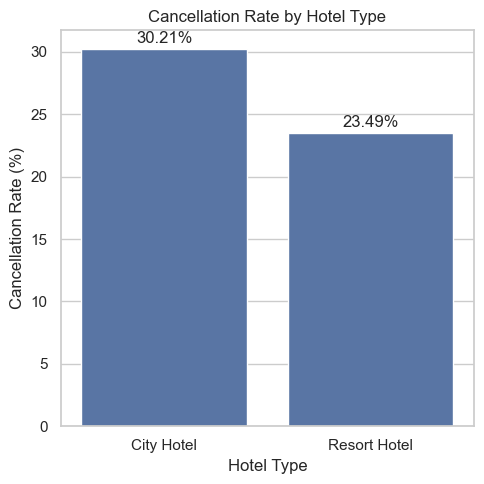

In [36]:
# Convert cancellation rate to a DataFrame for visualization
cancellation_rate_df = cancellation_rate.reset_index()
cancellation_rate_df.columns = ['hotel', 'cancellation_rate']

# Create a bar chart
plt.figure(figsize=(5, 5))

sns.barplot(
    data=cancellation_rate_df,
    x='hotel',
    y='cancellation_rate'
)

plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')

# Add percentage labels
for i, value in enumerate(cancellation_rate_df['cancellation_rate']):
    plt.text(
        i,
        value + 0.5,
        f'{value:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

**Chart Caption:** This chart compares the cancellation rate of City Hotel and Resort Hotel. City Hotel has a higher cancellation rate, indicating greater cancellation risk.

### Interpretation

The cancellation analysis shows that City Hotels have a higher cancellation rate than Resort Hotels.

The cancellation rate for City Hotels is **30.21%**, compared with **23.49%** for Resort Hotels. This means that nearly three out of every ten City Hotel bookings were canceled, while the cancellation rate for Resort Hotels was lower.

Although City Hotels received more total bookings, they also experienced a higher proportion of cancellations. This suggests that cancellation behaviour differs between the two hotel types and that City Hotels may face a greater risk of booking uncertainty.


## Impact of Stay Duration on Cancellation Rate

Stay duration means the **total number of nights a customer plans to stay at the hotel**. It is calculated by combining the number of weekend nights and weekday nights in each booking.

In this analysis, bookings are grouped based on their total stay duration, and the **cancellation rate is calculated for each group**. The chart will help us see whether cancellation behaviour changes as the length of stay increases.

The cancellation rates are also compared between **City Hotel and Resort Hotel** to understand whether stay duration affects cancellation behaviour differently for the two hotel types.

In [37]:
# Calculate total stay duration
df_clean['total_stay_nights'] = (
    df_clean['stays_in_weekend_nights'] +
    df_clean['stays_in_weekdays_nights']
)

# Check summary statistics
df_clean['total_stay_nights'].describe()

count    85962.000000
mean         3.640760
std          2.749453
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_stay_nights, dtype: float64

In [38]:
# Create stay duration groups
df_clean['stay_duration_group'] = pd.cut(
    df_clean['total_stay_nights'],
    bins=[0, 1, 3, 5, 7, float('inf')],
    labels=[
        '1 Night',
        '2-3 Nights',
        '4-5 Nights',
        '6-7 Nights',
        'More than 7 Nights'
    ],
    include_lowest=True
)

# Check the number of bookings in each group
df_clean['stay_duration_group'].value_counts().sort_index()

stay_duration_group
1 Night               17493
2-3 Nights            32859
4-5 Nights            20080
6-7 Nights            10713
More than 7 Nights     4817
Name: count, dtype: int64

In [39]:
# Calculate total bookings and cancellation rate
# by stay duration and hotel type

stay_duration_analysis = (
    df_clean
    .groupby(['stay_duration_group', 'hotel'], observed=False)
    .agg(
        total_bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

# Convert cancellation rate to percentage
stay_duration_analysis['cancellation_rate'] = (
    stay_duration_analysis['cancellation_rate'] * 100
).round(2)

stay_duration_analysis

,stay_duration_group,hotel,total_bookings,cancellation_rate
0,1 Night,City Hotel,10330,21.98
1,1 Night,Resort Hotel,7163,12.05
2,2-3 Nights,City Hotel,23825,30.70
3,2-3 Nights,Resort Hotel,9034,23.00
4,4-5 Nights,City Hotel,13643,31.64
5,4-5 Nights,Resort Hotel,6437,28.34
6,6-7 Nights,City Hotel,3469,37.53
7,6-7 Nights,Resort Hotel,7244,29.03
8,More than 7 Nights,City Hotel,1154,55.03
9,More than 7 Nights,Resort Hotel,3663,27.63


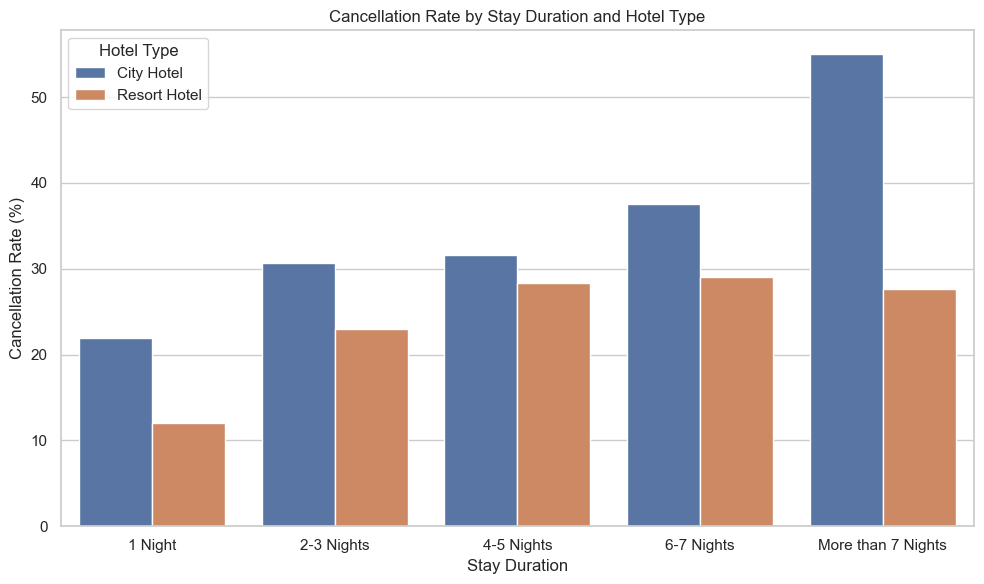

In [40]:
# Create cancellation rate chart by stay duration and hotel type

plt.figure(figsize=(10, 6))

sns.barplot(
    data=stay_duration_analysis,
    x='stay_duration_group',
    y='cancellation_rate',
    hue='hotel'
)

plt.title('Cancellation Rate by Stay Duration and Hotel Type')
plt.xlabel('Stay Duration')
plt.ylabel('Cancellation Rate (%)')
plt.legend(title='Hotel Type')

plt.tight_layout()
plt.show()

**Chart Caption:** This chart shows that cancellation rates generally increase as the length of stay increases. The increase is more noticeable for City Hotel, indicating higher cancellation risk for longer stays.

### Interpretation

The results show that stay duration is related to cancellation behaviour.

For City Hotel, the cancellation rate generally increases as the stay duration becomes longer. The cancellation rate increases from approximately 22% for one-night stays to approximately 55% for stays longer than seven nights.

For Resort Hotel, cancellation rates also generally increase as stay duration increases, but the pattern is less strong and remains lower than City Hotel.

This suggests that longer stays may have a higher cancellation risk, especially for City Hotel. One possible reason is that longer trips require more planning and have a higher total cost, which may increase the chance that customers change their travel plans.

## Impact of Lead Time on Cancellation Rate

Lead time means the **number of days between the date a booking is made and the customer's planned arrival date**.

In this analysis, bookings are grouped into different lead-time ranges to understand whether the time between booking and arrival is related to the likelihood of cancellation.

The chart compares the **cancellation rate for each lead-time group** between City Hotel and Resort Hotel. This helps us understand whether customers who book further in advance show different cancellation behaviour from those who book closer to their arrival date.

In [41]:
# Create lead time groups

df_clean['lead_time_group'] = pd.cut(
    df_clean['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, float('inf')],
    labels=[
        '0-7 Days',
        '8-30 Days',
        '31-90 Days',
        '91-180 Days',
        '181-365 Days',
        'More than 365 Days'
    ]
)

# Check the number of bookings in each lead time group
df_clean['lead_time_group'].value_counts().sort_index()

lead_time_group
0-7 Days              18064
8-30 Days             16185
31-90 Days            22368
91-180 Days           17952
181-365 Days          10866
More than 365 Days      527
Name: count, dtype: int64

In [42]:
# Calculate total bookings and cancellation rate
# by lead time and hotel type

lead_time_analysis = (
    df_clean
    .groupby(['lead_time_group', 'hotel'], observed=False)
    .agg(
        total_bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

# Convert cancellation rate to percentage
lead_time_analysis['cancellation_rate'] = (
    lead_time_analysis['cancellation_rate'] * 100
).round(2)

lead_time_analysis

,lead_time_group,hotel,total_bookings,cancellation_rate
0,0-7 Days,City Hotel,9728,10.54
1,0-7 Days,Resort Hotel,8336,5.95
2,8-30 Days,City Hotel,10414,27.96
3,8-30 Days,Resort Hotel,5771,20.83
4,31-90 Days,City Hotel,14885,33.42
5,31-90 Days,Resort Hotel,7483,29.68
6,91-180 Days,City Hotel,11341,36.73
7,91-180 Days,Resort Hotel,6611,32.13
8,181-365 Days,City Hotel,5699,45.18
9,181-365 Days,Resort Hotel,5167,34.84


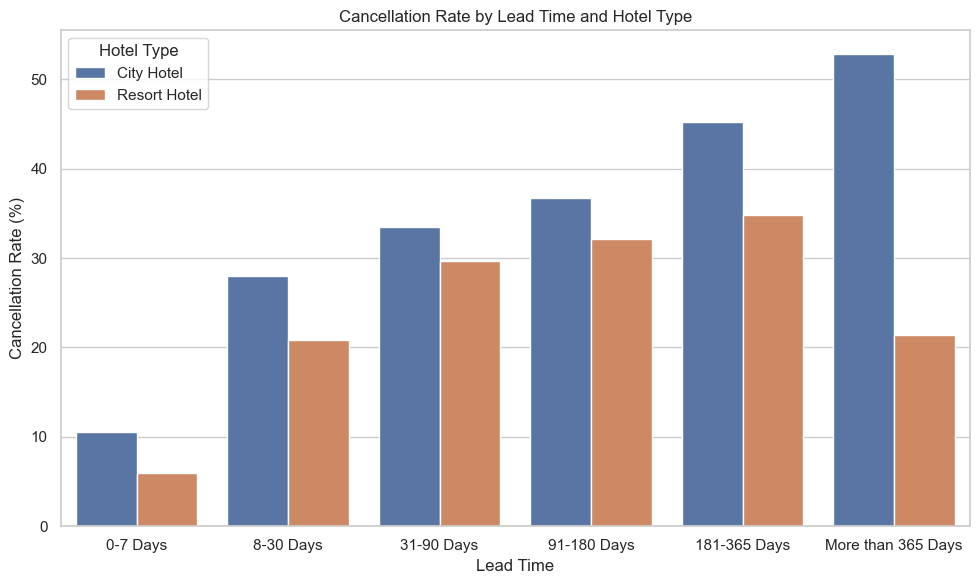

In [43]:
# Create cancellation rate chart by lead time and hotel type

plt.figure(figsize=(10, 6))

sns.barplot(
    data=lead_time_analysis,
    x='lead_time_group',
    y='cancellation_rate',
    hue='hotel'
)

plt.title('Cancellation Rate by Lead Time and Hotel Type')
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate (%)')
plt.legend(title='Hotel Type')

plt.tight_layout()
plt.show()

**Chart Caption:** This chart shows that cancellation rates generally increase when bookings are made further in advance. City Hotel shows a sharper increase in cancellation risk compared with Resort Hotel.

### Interpretation

The analysis shows a clear relationship between lead time and cancellation rate.

For City Hotel, the cancellation rate generally increases as the lead time increases. Bookings made close to the arrival date have a much lower cancellation rate than bookings made many months in advance.

Resort Hotel shows a similar general pattern, although the increase in cancellation rate is less extreme than City Hotel.

This suggests that bookings made far in advance have a higher risk of cancellation because customers have more time for their travel plans to change before the arrival date.

The results indicate that lead time is an important factor for identifying bookings with a higher cancellation risk.


## Combined Cancellation Risk Analysis

In the previous analyses, we looked at **stay duration** and **lead time** separately to understand their relationship with cancellation rate.

In this analysis, we combine these two factors to get a more complete view of **cancellation risk**. The heatmap will show how the cancellation rate changes for different combinations of stay duration and lead time.

By looking at both factors together, we can identify booking patterns where the cancellation rate is relatively higher. This can help hotel management understand which types of bookings may need **closer monitoring, confirmation, or follow-up**.

In [46]:
# Calculate cancellation rate by lead time and stay duration

combined_risk_analysis = (
    df_clean
    .groupby(
        ['lead_time_group', 'stay_duration_group'],
        observed=False
    )
    .agg(
        total_bookings=('is_canceled', 'size'),
        cancellation_rate=('is_canceled', 'mean')
    )
    .reset_index()
)

# Convert cancellation rate to percentage
combined_risk_analysis['cancellation_rate'] = (
    combined_risk_analysis['cancellation_rate'] * 100
)

combined_risk_analysis

,lead_time_group,stay_duration_group,total_bookings,cancellation_rate
0,0-7 Days,1 Night,9555,7.817896
1,0-7 Days,2-3 Nights,6139,8.063202
2,0-7 Days,4-5 Nights,1737,10.477835
3,0-7 Days,6-7 Nights,433,12.009238
4,0-7 Days,More than 7 Nights,200,22.500000
5,8-30 Days,1 Night,3601,22.216051
6,8-30 Days,2-3 Nights,7194,25.701974
7,8-30 Days,4-5 Nights,3724,25.429646
8,8-30 Days,6-7 Nights,1199,26.021685
9,8-30 Days,More than 7 Nights,467,44.111349


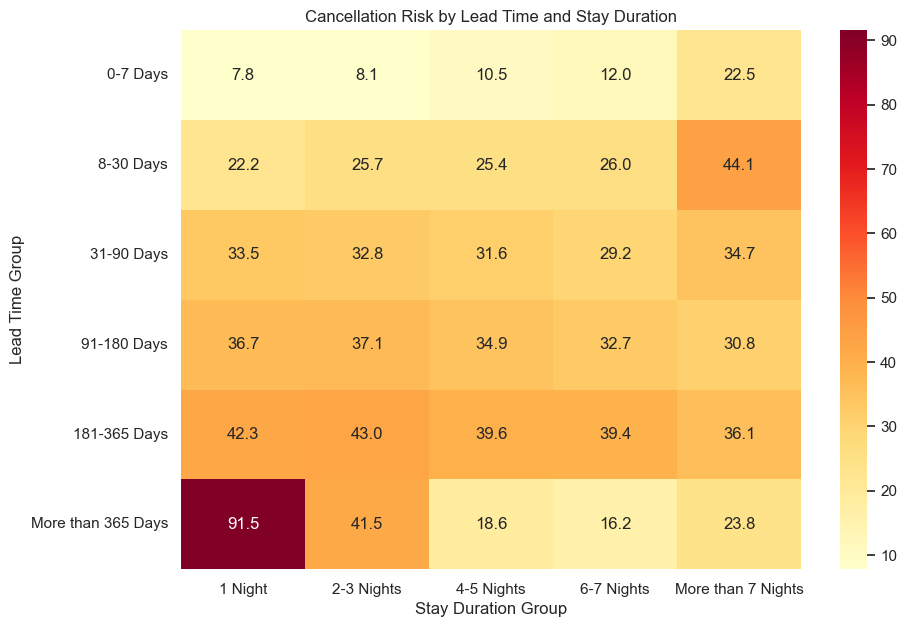

In [47]:
# Create pivot table for cancellation risk analysis

risk_pivot = combined_risk_analysis.pivot(
    index='lead_time_group',
    columns='stay_duration_group',
    values='cancellation_rate'
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    risk_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title(
    'Cancellation Risk by Lead Time and Stay Duration'
)

plt.xlabel('Stay Duration Group')
plt.ylabel('Lead Time Group')

plt.show()

**Chart Caption:** This heatmap combines lead time and stay duration to identify booking situations with higher cancellation risk. It helps the hotel identify booking segments that may require additional attention.

### Observation

The heatmap shows that cancellation rates vary depending on the combination of **lead time and stay duration**.

* For bookings made **0–7 days before arrival**, cancellation rates are generally low, ranging from **7.8% to 22.5%**.
* As lead time increases, cancellation rates generally become higher. For example, the **181–365 days** group has cancellation rates between **36.1% and 43.0%**.
* The **More than 365 Days** group shows a very high cancellation rate of **91.5%** in one stay-duration category. However, this value should be interpreted carefully because bookings in this group are relatively limited.
* The heatmap also shows that the relationship is **not perfectly consistent across all stay durations**. Some cells decrease even when lead time increases.
* Overall, bookings made **far in advance** contain several higher cancellation-risk segments compared with bookings made shortly before arrival.

This analysis shows that **lead time is an important factor in cancellation behaviour**, but the level of risk can also vary depending on stay duration. Therefore, hotels can use these booking patterns to identify segments that may need additional confirmation or monitoring.



# Summary and Business Recommendations

## Project Journey

In this project, we analyzed hotel booking data to understand **booking demand and cancellation behaviour** and to find useful patterns that can help hotel management make better decisions.

We started with the raw hotel booking dataset. Before doing any analysis, we first **cleaned and prepared the data**. This included checking missing values, removing duplicate records, handling unclear categories, checking unusual ADR values, and removing bookings where no guests were recorded. This step was important because incorrect or repeated records could affect our calculations and give misleading results.

After cleaning the data, we used **Exploratory Data Analysis (EDA)** to understand the booking data and find useful patterns. We first compared City Hotel and Resort Hotel to understand their overall booking demand. Then we looked at monthly booking trends to understand seasonal demand.

After that, we focused on **cancellation behaviour**. We compared cancellation rates between the two hotel types and then studied whether cancellation rates were related to **stay duration** and **lead time**. Finally, we combined lead time and stay duration in a heatmap to identify booking combinations that may have higher cancellation risk.

Through these analyses, we moved from simply looking at booking records to finding **patterns that can be useful for hotel business decisions**.

## Key Findings

### 1. City Hotel receives more bookings

City Hotel accounts for **60.98% of valid bookings**, with **52,421 bookings**, while Resort Hotel accounts for **39.02%**, with **33,541 bookings**.

This shows that City Hotel has higher overall booking demand in this dataset.

### 2. Cancellation behaviour is different for the two hotel types

City Hotel has an overall cancellation rate of **30.21%**, while Resort Hotel has a lower cancellation rate of **23.49%**.

This means City Hotel needs more attention when it comes to managing cancellation risk.

### 3. Stay duration can affect cancellation behaviour

The analysis shows that longer stays generally have higher cancellation rates, especially for City Hotel.

However, the pattern is not exactly the same for every stay-duration group or hotel type. This means stay duration can be considered as one factor when identifying bookings that may have a higher cancellation risk.

### 4. Lead time is an important cancellation factor

Bookings made further in advance generally show higher cancellation rates, particularly for City Hotel.

For City Hotel, the cancellation rate increases from **10.54% for bookings made 0–7 days before arrival** to **52.82% for bookings made more than 365 days in advance**.

This suggests that bookings made far before the arrival date may need more attention because there is more time for customers to change or cancel their plans.

### 5. Booking demand changes by month

The monthly analysis shows a clear seasonal pattern in booking demand.

**October has the highest booking volume**, while **March has the lowest booking volume** across the combined dataset.

This information can help hotels understand when demand is higher or lower and plan their operations accordingly.

### 6. Combining lead time and stay duration gives a better view of risk

The heatmap showed that cancellation risk changes based on the combination of **lead time and stay duration**.

Some combinations have much higher cancellation rates than others. Therefore, looking at multiple booking characteristics together can provide more useful information than looking at only one factor.

## Business Recommendations for Hotel Owners

Based on the analysis, the following actions can be recommended to hotel management:

### 1. Monitor bookings made far in advance

Bookings with long lead times should be monitored more carefully because they show higher cancellation risk, especially for City Hotel.

Hotels can send confirmation messages and reminders closer to the arrival date to make sure the customer still plans to visit.

### 2. Give more attention to City Hotel bookings

Since City Hotel has both higher booking volume and a higher cancellation rate, its management should focus more on cancellation monitoring.

The hotel can use booking information such as **lead time, stay duration, and arrival month** to identify bookings that may require additional attention.

### 3. Follow up on higher-risk long-stay bookings

Long-stay bookings can represent a higher cancellation-risk segment, particularly for City Hotel.

For these bookings, hotels can consider confirmation messages, reminders, suitable deposit policies, or flexible rebooking options where appropriate.

### 4. Use different strategies for different booking segments

Every booking does not have the same level of cancellation risk.

Instead of treating all customers in the same way, hotels can divide bookings into different risk segments based on factors such as **lead time and stay duration**. Higher-risk segments can receive more attention, while lower-risk bookings can follow the normal process.

### 5. Use monthly trends for business planning

The seasonal booking pattern can help hotel owners plan their operations according to expected demand.

During higher-demand months, hotels can prepare sufficient staff and room availability and review their pricing and promotional strategies. During lower-demand periods, they can consider suitable offers and marketing campaigns to attract more bookings.

## Recommendation With the Biggest Expected Impact

Among all the findings, **better management of bookings made far in advance** could have a strong impact on reducing cancellation-related problems.

The City Hotel analysis clearly shows that cancellation rates increase from **10.54% for bookings made 0–7 days before arrival to 52.82% for bookings made more than 365 days in advance**.

Therefore, lead time can be used as an important **early warning indicator**. Hotel management can identify bookings made far in advance and take suitable actions such as sending reminders, confirming the booking closer to arrival, or applying appropriate cancellation and deposit policies.

## Final Conclusion

This project helped us understand hotel booking behaviour from different business perspectives.

We found that **City Hotel receives more bookings but also has a higher cancellation rate than Resort Hotel**. We also found that booking demand changes across months, showing a seasonal pattern. Stay duration and lead time are also useful factors for understanding cancellation behaviour, with longer lead times showing a particularly strong relationship with cancellation risk for City Hotel.

The combined heatmap helped us look at **lead time and stay duration together** and identify booking segments where cancellation rates can be higher.

Overall, the analysis shows that hotel data can be used not only to understand what happened in the past, but also to support better business decisions. Hotel owners can use these insights to **monitor high-risk bookings, improve cancellation management, plan staff and room availability, adjust marketing strategies, and prepare for seasonal changes in demand**.

The main takeaway from this project is that **data-driven booking management can help hotels reduce avoidable cancellation impact and plan their operations more effectively**.

